# Angular correlation functions with `cloelib``

This is a notebook to demonstrate how to calculate angular correlation functions predicted with `cloelib` and compare the results against `CCL`. It uses redshift distributions that can be downloaded here: 'https://zenodo.org/records/15092862/files/nz_example.fits'

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy

In [ ]:
# niceplots import, if installed
# Can be found here: https://github.com/llinke1/niceplots/tree/main
import importlib.util

if importlib.util.find_spec("niceplots") is not None:
    import niceplots
    niceplots.initPlot()

In [4]:
# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el


In [5]:
# pyccl import
import pyccl as ccl

## Define cosmology

We first define a dictionary with cosmological parameters, that will be fed to both `cloelib`and `ccl`

In [ ]:
cosmo_dict = {
    'H0': 67.7,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'Omega_k':0,
    'omch2': 0.25*0.677**2,
    'ombh2': 0.05*0.677**2,
    'w0': -1,
    'wa':0,
    'ns':0.95,
    'As':2e-9,
    'mnu':0.0,
    'nnu':3.044,
    'Neff':3.044,
    'halofit_version':'mead2020'
}

# Redshift array to compute power spectra and define n(z)'s
zs = np.linspace(1e-4, 3., 256) 

# k array to compute powerspectra
ks=np.geomspace(1e-5, 300, 256)

#### CLOE cosmology

We define the `cloelib` background object, that contains the cosmological parameters

In [7]:
background = CAMBBackground(H0 = cosmo_dict['H0'], 
                            Omega_cdm0 = cosmo_dict['Omega_c'], 
                            Omega_b0 = cosmo_dict['Omega_b'], 
                            w0 = cosmo_dict['w0'], 
                            wa = cosmo_dict['wa'], 
                            Omega_k0 = cosmo_dict['Omega_k'], 
                            ns = cosmo_dict['ns'], 
                            As = cosmo_dict['As'],
                            mnu = cosmo_dict['mnu'],
                            gamma_MG=0
                            )

#### CCL cosmology

`CCL`has the `cosmology` object which is similar to the `cloelib``background`object

In [8]:
cosmo = ccl.Cosmology(h = cosmo_dict['H0']/100,
                      Omega_c = cosmo_dict['Omega_c'],
                      Omega_b = cosmo_dict['Omega_b'],
                      m_nu = cosmo_dict['mnu'],
                      Neff = cosmo_dict['Neff'], 
                      w0 = cosmo_dict['w0'],
                      wa = cosmo_dict['wa'],
                      Omega_k = cosmo_dict['Omega_k'],
                      n_s = cosmo_dict['ns'], 
                      A_s = cosmo_dict['As'],
                      matter_power_spectrum = 'camb', # linear / halofit / camb ...
                      extra_parameters = {'camb':{"halofit_version": cosmo_dict['halofit_version']}}, #    "HMCode_logT_AGN": 7.8} })
                      transfer_function='boltzmann_camb', # bbks / boltmann_class/_camb ...
                      T_ncdm=0
                      )

## Calculate matter power spectra

We first calculate the linear and nonlinear power spectra.

### CLOE

In [9]:
linear_perturbations = CAMBLinearPerturbations(background, zs)
nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, 
                                                     nonlinear_model = cosmo_dict['halofit_version'])


pk_lin_cloe = linear_perturbations.matter_power_spectrum(zs=zs, ks=ks)
pk_nl_cloe=nonlinear_perturbations.matter_power_spectrum(zs, ks)


Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


#### CCL

In [10]:
a=1/(zs+1)

pk_values_ccl = ccl.boltzmann.get_camb_pk_lin(cosmo, nonlin=True ) 
pk_lin_ccl = pk_values_ccl[0](ks, a) # (k, a)
pk_nl_ccl = pk_values_ccl[1](ks, a) 

#### Plot linear powerspectra
Just as a test, we here compare the linear power spectra of both codes at some redshift

/opt/anaconda3/envs/cloelib_env/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


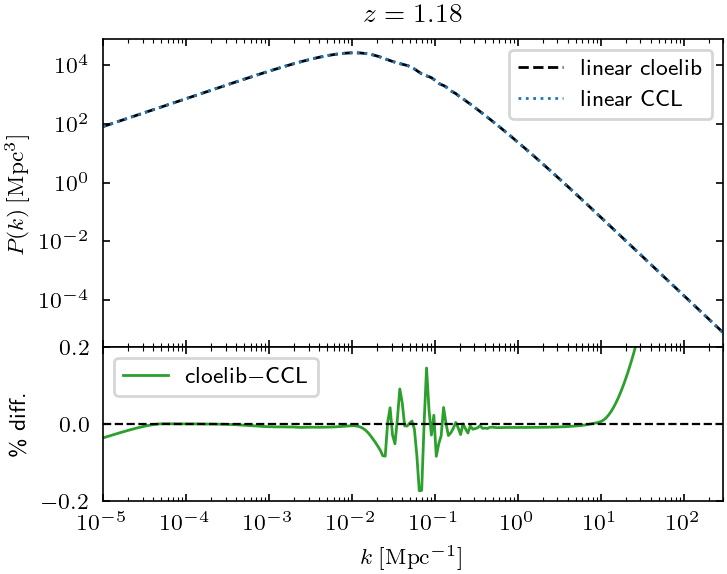

In [ ]:
ix=100 # index of redshift we want to compare the power spectra at

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
plt.subplots_adjust(hspace=0)


axs[0].set_title(f'$z={zs[ix]:.2f}$')
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$')
axs[0].loglog(ks,  pk_lin_cloe[ix], color='black', ls='--', label=r'{linear cloelib}')
axs[0].loglog(ks,  pk_lin_ccl[ix], color='tab:blue', ls=':', label=r'{linear CCL}')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\: [\rm{Mpc}^{-1}]$')
axs[1].set_ylabel(r'\% {diff.}')   
axs[1].plot(ks, (pk_lin_cloe[ix] - pk_lin_ccl[ix])/pk_lin_cloe[ix]*100, color='tab:green', ls='-', label=r'{cloelib$-$CCL')

axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-0.2, 0.2])
axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')





## Calculate $C(\ell)$

We now calculate the $C(\ell)$ with both codes

### Read in n(z)

The n(z) can be obtained here: 'https://zenodo.org/records/15092862/files/nz_example.fits'

In [ ]:
# read in for cloe

# Read the dndz (adapt to your filepath)
z_pos, dndz_pos = el.photo.redshift_distributions('nz_example.fits')
z_she, dndz_she = el.photo.redshift_distributions('nz_example.fits')



# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)
    

# Resampling the normalized n(z) with 256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
my_dndz_pos_norm = np.zeros([len(dndz_pos.keys()), 256])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(zs, z_pos, my_dndz_pos[i,:])


# Resampling the normalized n(z) with 256 values
my_dndz_she = np.vstack(list(dndz_she_norm.values()))
my_dndz_she_norm = np.zeros([len(dndz_she.keys()), 256])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(zs, z_she, my_dndz_she[i,:])


In [ ]:

# Setting colors for plots
if importlib.util.find_spec("niceplots") is not None:
    colors_pos=niceplots.getColorList(len(dndz_pos), cmap="viridis")
    colors_she=niceplots.getColorList(len(dndz_she), cmap="plasma")
else:
    cmap = plt.get_cmap("viridis")  # Choose a colormap
    colors_pos = [cmap(i) for i in np.linspace(0, 1, len(dndz_pos))]  
    cmap = plt.get_cmap("plasma")  # Choose a colormap
    colors_she = [cmap(i) for i in np.linspace(0, 1, len(dndz_pos))]  

In [ ]:
# read in for ccl

# Read the dndz
z_pos_ccl, dndz_pos_ccl = el.photo.redshift_distributions('nz_example.fits')
z_she_ccl, dndz_she_ccl = el.photo.redshift_distributions('nz_example.fits')

### Define tracers
Both codes work with `tracer`objects which we define here

In [16]:
# cloelib, ignore IA for now and use linear bias

tracer_pos_cloe = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model="linear",
                             nuisance_params={'b1': 1})

tracer_she_cloe = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 0, 'CIA': 0, 'EtaIA':0})


In [17]:
# ccl,  here you need different tracers for each tomo bin



tracer_pos_ccl={}
tracer_she_ccl={}

for tomobin in dndz_pos.keys():
    tracer_pos_ccl[tomobin]=ccl.NumberCountsTracer(cosmo, has_rsd=False, 
                                                   dndz=(zs, my_dndz_pos_norm[tomobin-1]), 
                                                   bias=(zs, np.ones_like(zs)))
    tracer_she_ccl[tomobin]=ccl.WeakLensingTracer(cosmo, 
                                                  dndz=(zs, my_dndz_she_norm[tomobin-1]),
                                                  ia_bias=None, use_A_ia=False)

#### Compute $C(\ell)$ CLOE

In [18]:
nl = 100
ells = np.logspace(1., np.log10(10000.), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
twopoint_shepos = AngularTwoPoint(tracer_she_cloe, tracer_pos_cloe)
twopoint_sheshe = AngularTwoPoint(tracer_she_cloe, tracer_she_cloe)

cells_gg_cloe = twopoint_pospos.get_Cl(ells, nl, ks)
cells_gE_cloe = twopoint_shepos.get_Cl(ells, nl, ks)
cells_EE_cloe = twopoint_sheshe.get_Cl(ells, nl, ks)

#### Compute $C(\ell)$ CCL

In [19]:
#CCL Power spectra
cells_gg_ccl={}
cells_gE_ccl={}
cells_EE_ccl={}
for tomobin in dndz_pos.keys():
    cells_gg_ccl[tomobin] = ccl.angular_cl(cosmo, tracer_pos_ccl[tomobin], 
    tracer_pos_ccl[tomobin], ells)
    cells_gE_ccl[tomobin] = ccl.angular_cl(cosmo, tracer_she_ccl[tomobin], 
    tracer_pos_ccl[tomobin], ells) 
    cells_EE_ccl[tomobin] = ccl.angular_cl(cosmo, tracer_she_ccl[tomobin], 
    tracer_she_ccl[tomobin], ells) 

#### Plot $C(\ell)$
Just as a test we compare the $C(\ell)$ of both codes.

/opt/anaconda3/envs/cloelib_env/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


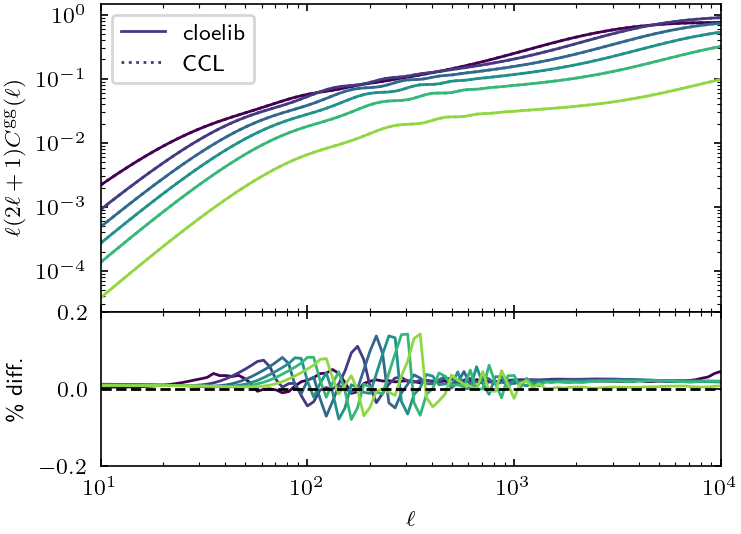

In [20]:
probe = 'gg' # Galaxy clustering
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'\% diff.')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_pos[i], label = r'{cloelib}')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], color=colors_pos[i], ls=':', label = r'{CCL}')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_pos[i])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], ls=':', color=colors_pos[i])

    axs[1].plot(ells, (cells_ccl[i+1] - cells_cloe[:, i, i])/cells_ccl[i+1]*100, color=colors_pos[i])

axs[1].set_ylim([-0.2, 0.2])
axs[0].legend()
axs[1].axhline(0, 0, 3e3, ls='--', color='black')




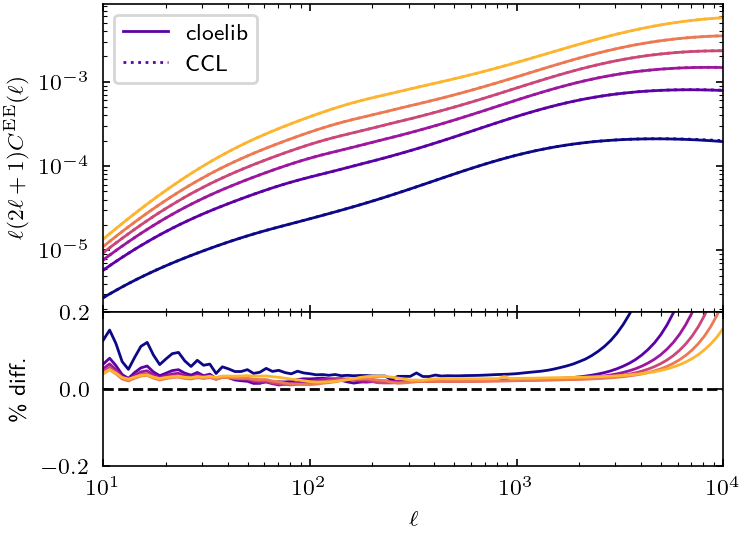

In [21]:
probe = 'EE' # Galaxy clustering
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'\% diff.')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_she[i], label = r'{cloelib}')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], color=colors_she[i], ls=':', label = r'{CCL}')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_she[i])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], ls=':', color=colors_she[i])

    axs[1].plot(ells, (cells_ccl[i+1] - cells_cloe[:, i, i])/cells_ccl[i+1]*100, color=colors_she[i])

axs[1].set_ylim([-0.2, 0.2])
axs[0].legend()
axs[1].axhline(0, 0, 3e3, ls='--', color='black')




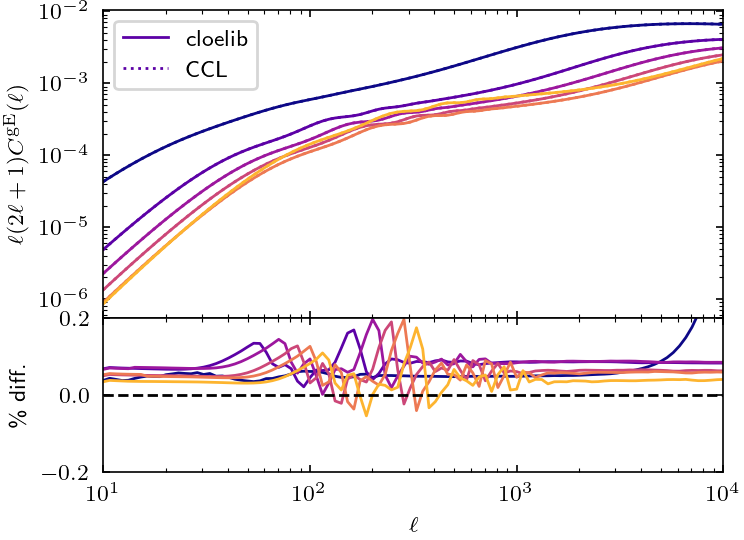

In [22]:
probe = 'gE' # Galaxy clustering
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'\% diff.')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_she[i], label = r'cloelib')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], color=colors_she[i], ls=':', label = r'CCL')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=colors_she[i])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[i+1], ls=':', color=colors_she[i])

    axs[1].plot(ells, (cells_ccl[i+1] - cells_cloe[:, i, i])/cells_ccl[i+1]*100, color=colors_she[i])

axs[1].set_ylim([-0.2, 0.2])
axs[0].legend()
axs[1].axhline(0, 0, 3e3, ls='--', color='black')




## Calculate Angular Correlation functions
We now compute the angular correlation functions.

In [23]:
# thetas

theta_deg = np.geomspace(5, 100, 20)/60 # Theta is in degrees

theta_rad = np.deg2rad(theta_deg)  # Angles in radians


# ells for integration
ells_integration = np.arange(2, 60000)  # Multipole moments
ks = nonlinear_perturbations.k  # Wavenumber grid

### Position-Position

In [24]:
# cloelib calcilation

correlation_function_GG = AngularCorrelationFunctionWigner(twopoint_pospos, ells_integration, ks)
xi_pospos = correlation_function_GG.get_xi(theta_rad)


In [25]:
#ccl calculation

xi_pospos_ccl={}

for tomobin in dndz_pos:
    xi_pospos_ccl[tomobin]=ccl.correlation(cosmo, ell=ells_integration, 
                                            C_ell=ccl.angular_cl(cosmo, tracer_pos_ccl[tomobin], 
    tracer_pos_ccl[tomobin], ells_integration), theta=theta_deg, type='NN', method='Bessel')


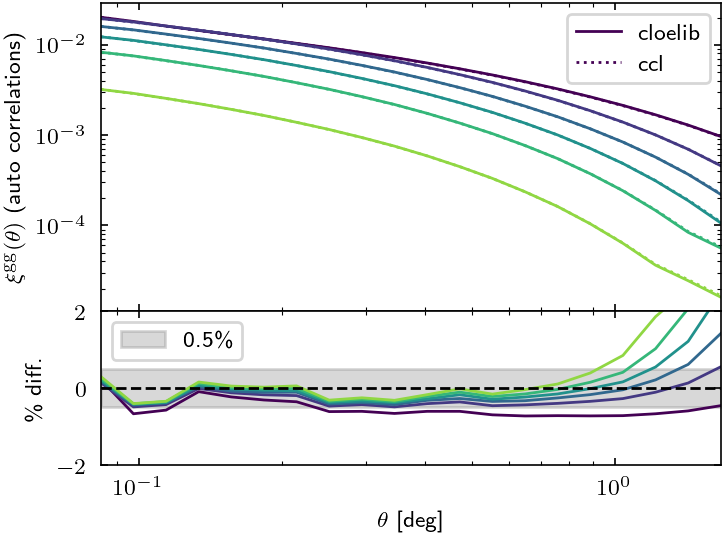

In [26]:
# plot

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)


for i in range(0, 6):
    if i==0:
        axs[0].loglog(theta_deg, xi_pospos[:, i, i], label = f"cloelib", c=colors_pos[i])
        axs[0].loglog(theta_deg, xi_pospos_ccl[i+1], label = f"ccl", c=colors_pos[i], ls=':')
    else:
        axs[0].loglog(theta_deg, xi_pospos[:, i, i], c=colors_pos[i])
        axs[0].loglog(theta_deg, xi_pospos_ccl[i+1], c=colors_pos[i], ls=':')
    axs[1].plot(theta_deg, (xi_pospos_ccl[i+1] - xi_pospos[:, i, i])/xi_pospos_ccl[i+1]*100, color=colors_pos[i])

axs[1].axhline(0, ls='--', color='k')

axs[1].set_xlabel(r'$\theta$ [deg]')
axs[0].set_ylabel(r'$\xi^{\rm gg}(\theta)$ (auto correlations)')
axs[1].set_ylabel(r'\% diff.')

axs[0].legend()
axs[1].set_ylim([-2, 2])
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3, label=r'0.5\%')
axs[1].legend()


#### Shear-Position

In [27]:
# cloelib calcilation

correlation_function_EG = AngularCorrelationFunctionWigner(twopoint_shepos, ells_integration, ks)
xi_shepos = correlation_function_EG.get_xi(theta_rad)


In [28]:
#ccl calculation

xi_shepos_ccl={}

for tomobin in dndz_pos:
    xi_shepos_ccl[tomobin]=ccl.correlation(cosmo, ell=ells_integration, 
                                            C_ell=ccl.angular_cl(cosmo, tracer_pos_ccl[tomobin], 
    tracer_she_ccl[tomobin], ells_integration), theta=theta_deg, type='NG', method='Bessel')


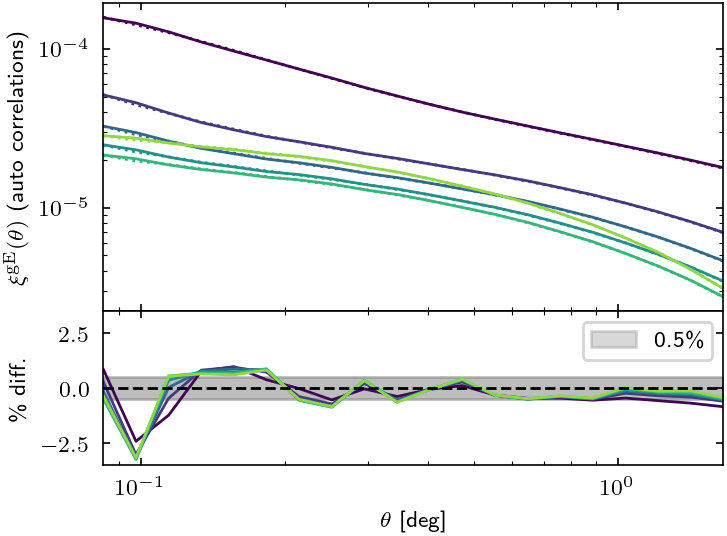

In [29]:
# plot

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)


for i in range(0, 6):
    axs[0].loglog(theta_deg, xi_shepos[:, i, i], label = f"bin {i}, cloelib", c=colors_pos[i])
    axs[0].loglog(theta_deg, xi_shepos_ccl[i+1], label = f"bin {i}, ccl", c=colors_pos[i], ls=':')

    axs[1].plot(theta_deg, (xi_shepos_ccl[i+1] - xi_shepos[:, i, i])/xi_shepos_ccl[i+1]*100, color=colors_pos[i])

axs[1].axhline(0, ls='--', color='k')

axs[1].set_xlabel(r'$\theta$ [deg]')
axs[0].set_ylabel(r'$\xi^{\rm gE}(\theta)$ (auto correlations)')
axs[1].set_ylabel(r'\% diff.')

#axs[0].legend(ncols=2)
axs[1].set_ylim([-3.5, 3.5])
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3)
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3, label=r'0.5\%')
axs[1].legend()



#### Shear-Shear

In [30]:
# cloelib calcilation

ells_integration=np.arange(2, 30000)
correlation_function_EE = AngularCorrelationFunctionWigner(twopoint_sheshe, ells_integration, ks)
xi_sheshe_plus, xi_sheshe_minus = correlation_function_EE.get_xi(theta_rad)


In [31]:
#ccl calculation

xi_sheshe_plus_ccl={}
xi_sheshe_minus_ccl={}


for tomobin in dndz_she:
    xi_sheshe_plus_ccl[tomobin]=ccl.correlation(cosmo, ell=ells_integration, 
     C_ell=ccl.angular_cl(cosmo, tracer_she_ccl[tomobin], 
    tracer_she_ccl[tomobin], ells_integration), theta=theta_deg, type='GG+', method='Bessel')
    
    
    xi_sheshe_minus_ccl[tomobin]=ccl.correlation(cosmo, ell=ells_integration, 
     C_ell=ccl.angular_cl(cosmo, tracer_she_ccl[tomobin], 
    tracer_she_ccl[tomobin], ells_integration), theta=theta_deg, type='GG-', method='Bessel')
    



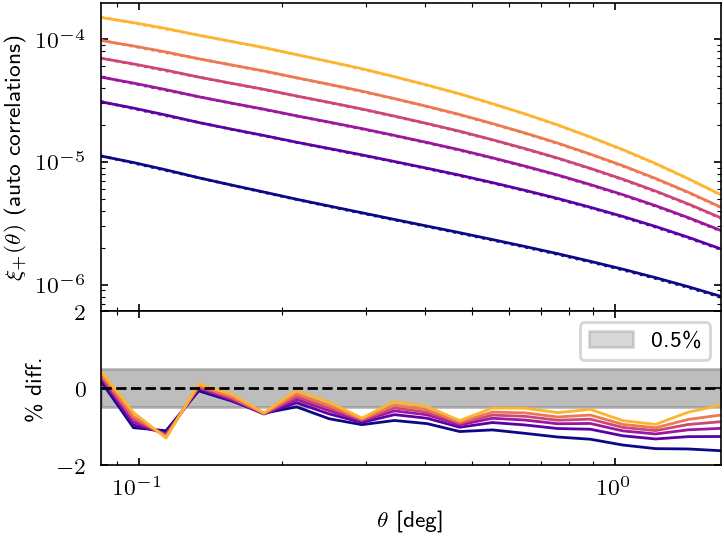

In [32]:
# plot

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)


for i in range(0, 6):
    axs[0].loglog(theta_deg, xi_sheshe_plus[:, i, i], label = f"bin {i}, cloelib", c=colors_she[i])
    axs[0].loglog(theta_deg, xi_sheshe_plus_ccl[i+1], label = f"bin {i}, ccl", c=colors_she[i], ls=':')

    axs[1].plot(theta_deg, (xi_sheshe_plus_ccl[i+1] - xi_sheshe_plus[:, i, i])/xi_sheshe_plus_ccl[i+1]*100, color=colors_she[i])

axs[1].axhline(0, ls='--', color='k')

axs[1].set_xlabel(r'$\theta$ [deg]')
axs[0].set_ylabel(r'$\xi_+(\theta)$ (auto correlations)')
axs[1].set_ylabel(r'\% diff.')

#axs[0].legend(ncols=2)
axs[1].set_ylim([-2, 2])
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3)
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3, label=r'0.5\%')
axs[1].legend()



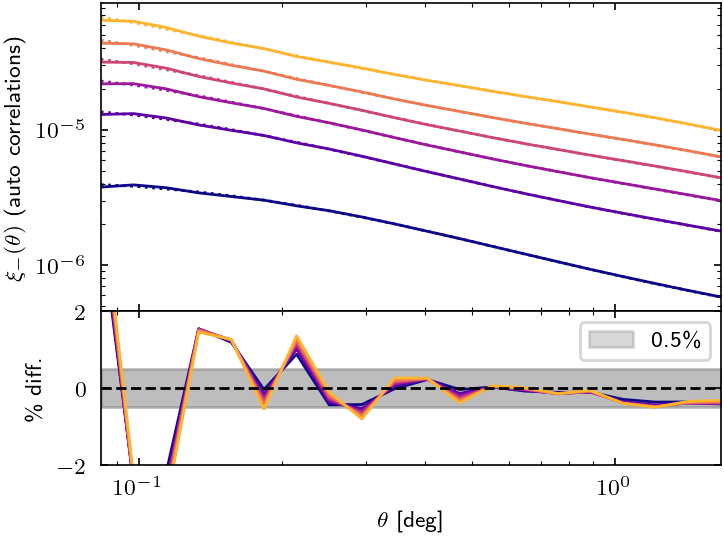

In [33]:
# plot

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0)


for i in range(0, 6):
    axs[0].loglog(theta_deg, xi_sheshe_minus[:, i, i], label = f"bin {i}, cloelib", c=colors_she[i])
    axs[0].loglog(theta_deg, xi_sheshe_minus_ccl[i+1], label = f"bin {i}, ccl", c=colors_she[i], ls=':')

    axs[1].plot(theta_deg, (xi_sheshe_minus_ccl[i+1] - xi_sheshe_minus[:, i, i])/xi_sheshe_minus_ccl[i+1]*100, color=colors_she[i])

axs[1].axhline(0, ls='--', color='k')

axs[1].set_xlabel(r'$\theta$ [deg]')
axs[0].set_ylabel(r'$\xi_-(\theta)$ (auto correlations)')
axs[1].set_ylabel(r'\% diff.')

#axs[0].legend(ncols=2)
axs[1].set_ylim([-2, 2])
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3)
axs[1].fill_between(theta_deg, -0.5, 0.5, color='grey', alpha=0.3, label=r'0.5\%')
axs[1].legend()

